<a href="https://colab.research.google.com/github/KowshiqKatta/Generative-AI/blob/main/LangGraph/conditional_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):

  a: int
  b: int
  c: int

  equation: str
  discriminant: float
  result: str

In [10]:
def show_equation(state: QuadState) -> QuadState:
  equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]}'
  return {'equation': equation}

def calculate_discriminant(state: QuadState) -> QuadState:
  discriminant = state["b"] ** 2 - 4 * state["a"] * state["c"]
  return {'discriminant': discriminant}

def real_roots(state: QuadState):
  root1 = (-state["b"] + state["discriminant"] ** 0.5) / (2 * state["a"])
  root2 = (-state["b"] - state["discriminant"] ** 0.5) / (2 * state["a"])
  result = f"The roots are {root1} and {root2}"
  return {'result': result}

def repeated_roots(state: QuadState):
  root = (-state["b"]) / (2 * state["a"])
  result = f"Only repeating root is {root}"
  return {'result': result}

def no_real_roots(state: QuadState):
  result = f"No real roots"
  return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
  if state["discriminant"] > 0:
    return "real_roots"
  elif state["discriminant"] == 0:
    return "repeated_roots"
  else:
    return "no_real_roots"


In [11]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

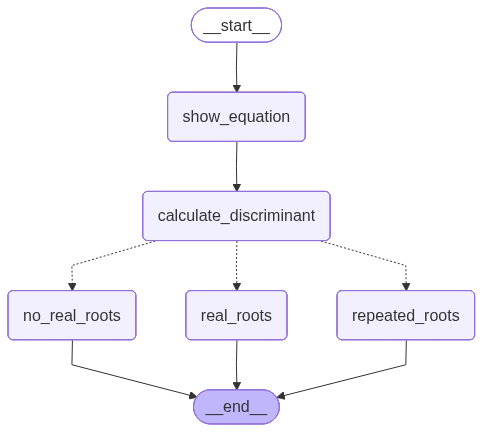

In [12]:
workflow

In [13]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x^2 + -5x + -4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}

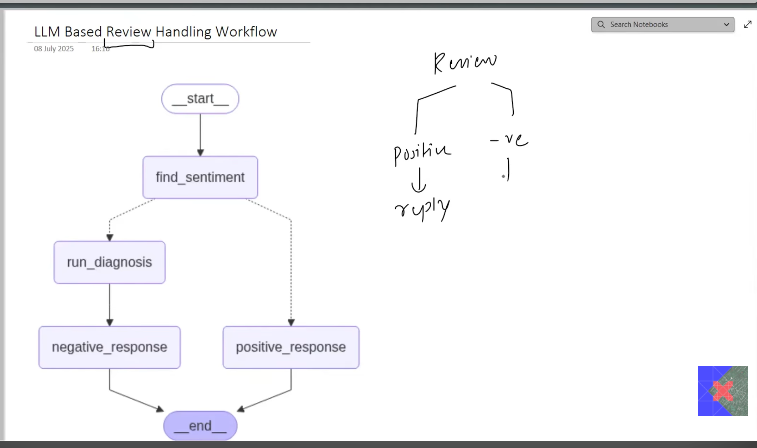

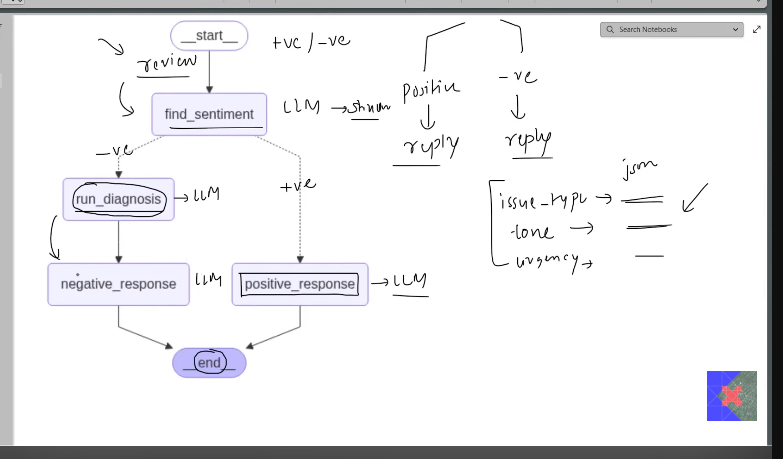

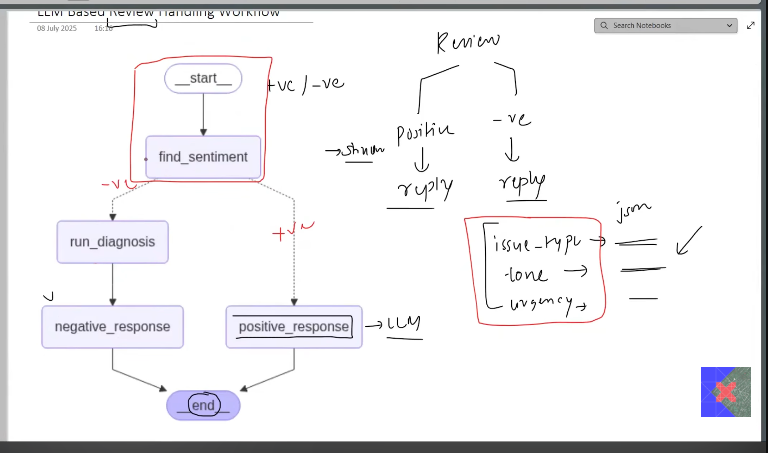

In [15]:
!!pip install langchain_openai

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

In [18]:
import os
os.environ["OPENAI_API_KEY"] = "YOUR-API-KEY"
model = ChatOpenAI(model = 'gpt-4o-mini')

In [29]:
class SentimentSchema(BaseModel):

  sentiment: Literal["positive", "negative"] = Field(description = "Sentiment of the review")

class DiagnosisSchema(BaseModel):

  issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
  tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
  urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [30]:
structured_model = model.with_structured_output(SentimentSchema)

structured_model2 = model.with_structured_output(DiagnosisSchema)

In [21]:
class ReviewState(TypedDict):

  review: str
  sentiment: Literal["positive", "negative"]
  diagnosis: dict
  response: str

In [31]:
def find_sentiment(state: ReviewState):

  prompt = f"For the following review find out the sentiment \n {state["review"]}"
  sentiment = structured_model.invoke(prompt).sentiment

  return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

  if state['sentiment'] == 'positive':
    return 'positive_response'
  else:
    return 'run_diagnosis'

def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}



In [32]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()


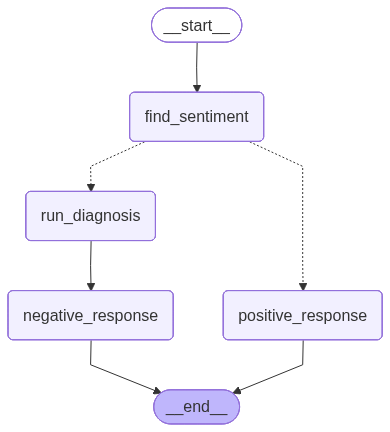

In [33]:
workflow

In [34]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Issue\n\nHi [User's Name],\n\nI hope this message finds you well. I truly understand how frustrating it can be to encounter a bug, especially when you need everything to be working smoothly. Your concerns are important to us, and I want to assure you that we're here to help resolve this issue as quickly as possible.\n\nCould you please provide me with some additional details about the bug you’re experiencing? Any specific error messages, screenshots, or steps to replicate the issue would be incredibly helpful. This information will allow us to diagnose the problem more effectively and work to